In [ ]:
#Aqui cargamos las librerias que usaremos para el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#Los datasets son cargados desde Google Drive, entonces creamos una variable para almacenar la url de cada dataset
#los dataset se modificaron  se omitieron algunos datos, para hacer mas accesible su lectura
#Dataset razones no conexion tomado de:(modulo 2.4) https://www.dane.gov.co/index.php/estadisticas-por-tema/tecnologia-e-innovacion/tecnologias-de-la-informacion-y-las-comunicaciones-tic/encuesta-de-tecnologias-de-la-informacion-y-las-comunicaciones-en-hogares-entic-hogares
urlRazonesNoConexion = 'https://github.com/V4nch/Datos-Proyecto/raw/refs/heads/main/RazonesNoConexion%20(1).xlsx'
#Dataset carasteristicas no conexion tomado de:(modulo 2.2) https://www.dane.gov.co/index.php/estadisticas-por-tema/tecnologia-e-innovacion/tecnologias-de-la-informacion-y-las-comunicaciones-tic/encuesta-de-tecnologias-de-la-informacion-y-las-comunicaciones-en-hogares-entic-hogares
urlCaracteristicasConexion = 'https://github.com/V4nch/Datos-Proyecto/raw/refs/heads/main/caracteristicaConexionInternet.xlsx'
#Dataset internetFijo tomado de: https://www.datos.gov.co/Ciencia-Tecnolog-a-e-Innovaci-n/Internet-Fijo-Penetraci-n-Departamentos/4py7-br84/about_data
urlInterneFijo = 'https://raw.githubusercontent.com/V4nch/Datos-Proyecto/refs/heads/main/Internet_Fijo_Penetraci_n_Municipio_20250422.csv'
#Creamos una Variable para almacenar y cargar cada set
razonesNoConexion = pd.read_excel(urlRazonesNoConexion)
caracteristicasConexion = pd.read_excel(urlCaracteristicasConexion)
interneFijo = pd.read_csv(urlInterneFijo)

In [ ]:
#Exploracion dataset
razonesNoConexion.head()

,DEPARTAMENTO,HOGARES SIN CONEXIÓN A INTERNET,Es muy costoso,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad
0,AMAZONAS,14296.333491,5641.500364,3051.517455,1088.593693,178.644215,739.722100,3570.516685,25.838979
1,ANTIOQUIA,853438.725064,428997.464126,216891.401817,42185.982201,25198.402298,62728.265063,77437.209559,0.000000
2,ARAUCA,69760.848254,36053.497406,14107.519723,3411.634899,2635.326810,2992.245025,10545.287603,15.336788
3,ATLÁNTICO,353027.225750,213128.248045,56228.425171,39528.126601,10360.933771,15307.445686,17728.060359,745.986118
4,"BOGOTÁ, D.C.",540335.214487,221860.723020,158343.434069,35748.734105,20811.512825,101411.309457,2159.501011,0.000000


In [ ]:
razonesNoConexion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   DEPARTAMENTO                                           33 non-null     object 
 1   HOGARES SIN CONEXIÓN A INTERNET                        33 non-null     float64
 2   Es muy costoso                                         33 non-null     float64
 3   No lo considera necesario                              33 non-null     float64
 4   No tiene un dispositivo para conectarse                33 non-null     float64
 5   Tiene acceso suficiente desde otros lugares sin costo  33 non-null     float64
 6   No sabe usarlo                                         33 non-null     float64
 7   No hay cobertura en la zona                            33 non-null     float64
 8   Por razones de seguridad                             

In [ ]:
#convertimos los datos a entero (no es posible que existan 14296.333491 personas)
columnasConvertir =["HOGARES SIN CONEXIÓN A INTERNET",'Es muy costoso','No lo considera necesario','No tiene un dispositivo para conectarse','Tiene acceso suficiente desde otros lugares sin costo','No sabe usarlo','No hay cobertura en la zona','Por razones de seguridad']
razonesNoConexion[columnasConvertir] = razonesNoConexion[columnasConvertir].astype(int)
razonesNoConexion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   DEPARTAMENTO                                           33 non-null     object
 1   HOGARES SIN CONEXIÓN A INTERNET                        33 non-null     int64 
 2   Es muy costoso                                         33 non-null     int64 
 3   No lo considera necesario                              33 non-null     int64 
 4   No tiene un dispositivo para conectarse                33 non-null     int64 
 5   Tiene acceso suficiente desde otros lugares sin costo  33 non-null     int64 
 6   No sabe usarlo                                         33 non-null     int64 
 7   No hay cobertura en la zona                            33 non-null     int64 
 8   Por razones de seguridad                               33 non-n

In [ ]:
razonesNoConexion.head()

,DEPARTAMENTO,HOGARES SIN CONEXIÓN A INTERNET,Es muy costoso,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad
0,AMAZONAS,14296,5641,3051,1088,178,739,3570,25
1,ANTIOQUIA,853438,428997,216891,42185,25198,62728,77437,0
2,ARAUCA,69760,36053,14107,3411,2635,2992,10545,15
3,ATLÁNTICO,353027,213128,56228,39528,10360,15307,17728,745
4,"BOGOTÁ, D.C.",540335,221860,158343,35748,20811,101411,2159,0


In [ ]:
#Revisando si tiene nulos
razonesNoConexion.isnull().sum()

,0
DEPARTAMENTO,0
HOGARES SIN CONEXIÓN A INTERNET,0
Es muy costoso,0
No lo considera necesario,0
No tiene un dispositivo para conectarse,0
Tiene acceso suficiente desde otros lugares sin costo,0
No sabe usarlo,0
No hay cobertura en la zona,0
Por razones de seguridad,0


In [ ]:
#Exploracion dataset
caracteristicasConexion.head()


,DEPARTAMENTO,HOGARES CON INTERNET,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO,HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL,VALOR PROMEDIO MENSUAL( Menos de $20.000),VALOR PROMEDIO MENSUAL( De $20.000 a $30.000),VALOR PROMEDIO MENSUAL( De $30.001 a $50.000),VALOR PROMEDIO MENSUAL( De $50.001 a $80.000),VALOR PROMEDIO MENSUAL( De $80.001 a $120.000),VALOR PROMEDIO MENSUAL( De $120.001 a $180.000),VALOR PROMEDIO MENSUAL( de $180.000)
0,AMAZONAS,6.539843e+03,3.227754e+02,6.376916e+03,159.848822,8.084166,50.267248,13.266127,75.698071,11.792113,16.557209,147.110467
1,ANTIOQUIA,1.474873e+06,1.261458e+06,3.306445e+05,117228.920684,27444.428879,38497.365532,231395.603950,509666.108895,221847.531959,139619.255377,92987.434569
2,ARAUCA,3.681744e+04,2.074943e+04,1.818050e+04,2112.490835,145.688302,338.591239,2998.406310,11650.948728,3259.702065,466.614265,1889.476986
3,ATLÁNTICO,4.011738e+05,3.409652e+05,1.144527e+05,54244.190835,8597.382831,21498.356085,113940.964413,106101.681420,65243.436358,25325.510222,257.889841
4,"BOGOTÁ, D.C.",2.324588e+06,1.964793e+06,1.276576e+06,916781.340751,40359.213309,108900.479142,351046.566798,718067.296097,561806.634512,168489.841911,16122.639336


In [ ]:
caracteristicasConexion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 12 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   DEPARTAMENTO                                            33 non-null     object 
 1   HOGARES CON INTERNET                                    33 non-null     float64
 2   HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO          33 non-null     float64
 3   HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL         33 non-null     float64
 4   HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL  33 non-null     float64
 5   VALOR PROMEDIO MENSUAL( Menos de $20.000)               33 non-null     float64
 6   VALOR PROMEDIO MENSUAL(  De $20.000 a $30.000)          33 non-null     float64
 7   VALOR PROMEDIO MENSUAL(  De $30.001 a $50.000)          33 non-null     float64
 8   VALOR PROMEDIO MENSUAL(  De $50.001 a $80.

In [ ]:
#convertir datos tipo float a entero explicado anteriormente

columnasConvertirCaracteristicas = ['HOGARES CON INTERNET','HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO','HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL','HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL','VALOR PROMEDIO MENSUAL( Menos de $20.000)','VALOR PROMEDIO MENSUAL(  De $20.000 a $30.000)','VALOR PROMEDIO MENSUAL(  De $30.001 a $50.000)','VALOR PROMEDIO MENSUAL(  De $50.001 a $80.000)','VALOR PROMEDIO MENSUAL(  De $80.001 a $120.000)','VALOR PROMEDIO MENSUAL(  De $120.001 a $180.000)','VALOR PROMEDIO MENSUAL(  de $180.000)']
caracteristicasConexion[columnasConvertirCaracteristicas] = caracteristicasConexion[columnasConvertirCaracteristicas].astype(int)
caracteristicasConexion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 12 columns):
 #   Column                                                  Non-Null Count  Dtype 
---  ------                                                  --------------  ----- 
 0   DEPARTAMENTO                                            33 non-null     object
 1   HOGARES CON INTERNET                                    33 non-null     int64 
 2   HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO          33 non-null     int64 
 3   HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL         33 non-null     int64 
 4   HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL  33 non-null     int64 
 5   VALOR PROMEDIO MENSUAL( Menos de $20.000)               33 non-null     int64 
 6   VALOR PROMEDIO MENSUAL(  De $20.000 a $30.000)          33 non-null     int64 
 7   VALOR PROMEDIO MENSUAL(  De $30.001 a $50.000)          33 non-null     int64 
 8   VALOR PROMEDIO MENSUAL(  De $50.001 a $80.000)      

In [ ]:
#Revisando si tiene nulos
caracteristicasConexion.isnull().sum()

,0
DEPARTAMENTO,0
HOGARES CON INTERNET,0
HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO,0
HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL,0
HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL,0
VALOR PROMEDIO MENSUAL( Menos de $20.000),0
VALOR PROMEDIO MENSUAL( De $20.000 a $30.000),0
VALOR PROMEDIO MENSUAL( De $30.001 a $50.000),0
VALOR PROMEDIO MENSUAL( De $50.001 a $80.000),0
VALOR PROMEDIO MENSUAL( De $80.001 a $120.000),0


In [ ]:
#Exploracion dataset
interneFijo.head()

,AÑO,TRIMESTRE,COD_DEPARTAMENTO,DEPARTAMENTO,COD_MUNICIPIO,MUNICIPIO,No. ACCESOS FIJOS A INTERNET,POBLACIÓN DANE,INDICE
0,2016,1,50,META,50606,RESTREPO,490,17648,"2,78"
1,2016,2,15,BOYACÁ,15518,PAJARITO,43,2395,"1,80"
2,2020,3,25,CUNDINAMARCA,25489,NIMAIMA,43,3808,"1,13"
3,2020,3,73,TOLIMA,73030,AMBALEMA,38,6752,"0,56"
4,2017,1,5,ANTIOQUIA,5690,SANTO DOMINGO,337,12426,"2,71"


In [ ]:
#revisando si tiene nulos
interneFijo.isnull().sum()

,0
AÑO,0
TRIMESTRE,0
COD_DEPARTAMENTO,0
DEPARTAMENTO,0
COD_MUNICIPIO,0
MUNICIPIO,0
No. ACCESOS FIJOS A INTERNET,0
POBLACIÓN DANE,0
INDICE,0


In [ ]:
#aplicamos un filtro para ver solo los registros que nos sirven ( en este caso los del año 2021)
filtro2021 = interneFijo['AÑO'] == 2021
internet2021 = interneFijo[filtro2021]
internet2021.head(10)


,AÑO,TRIMESTRE,COD_DEPARTAMENTO,DEPARTAMENTO,COD_MUNICIPIO,MUNICIPIO,No. ACCESOS FIJOS A INTERNET,POBLACIÓN DANE,INDICE
704,2021,4,13,BOLÍVAR,13140,CALAMAR,564,24034,"2,35"
727,2021,2,20,CESAR,20011,AGUACHICA,11927,121581,"9,81"
813,2021,1,52,NARIÑO,52490,OLAYA HERRERA,94,25969,"0,36"
933,2021,1,99,VICHADA,99624,SANTA ROSALÍA,9,4367,"0,21"
1026,2021,4,13,BOLÍVAR,13549,PINILLOS,47,25814,"0,18"
1093,2021,2,15,BOYACÁ,15047,AQUITANIA,832,15950,"5,22"
1162,2021,2,70,SUCRE,70265,GUARANDA,29,18464,"0,16"
1182,2021,2,15,BOYACÁ,15820,TÓPAGA,114,3749,"3,04"
1218,2021,2,13,BOLÍVAR,13244,EL CARMEN DE BOLÍVAR,2811,74331,"3,78"
1407,2021,3,50,META,50573,PUERTO LÓPEZ,2351,32091,"7,33"


In [ ]:
#aplicamos un filtro para explorar con mejor claridad los datos
bolivar = internet2021['DEPARTAMENTO'] == 'AMAZONAS'
internetBolivar = internet2021[bolivar]
internetBolivar.head(20)

,AÑO,TRIMESTRE,COD_DEPARTAMENTO,DEPARTAMENTO,COD_MUNICIPIO,MUNICIPIO,No. ACCESOS FIJOS A INTERNET,POBLACIÓN DANE,INDICE
1778,2021,3,91,AMAZONAS,91798,TARAPACÁ,21,4159,"0,50"
2001,2021,2,91,AMAZONAS,91798,TARAPACÁ,19,4159,"0,46"
2147,2021,4,91,AMAZONAS,91530,PUERTO ALEGRÍA,1,758,"0,13"
2408,2021,4,91,AMAZONAS,91536,PUERTO ARICA,2,1045,"0,19"
2668,2021,3,91,AMAZONAS,91263,EL ENCANTO,4,2074,"0,19"
3064,2021,3,91,AMAZONAS,91540,PUERTO NARIÑO,35,10418,"0,34"
3340,2021,4,91,AMAZONAS,91001,LETICIA,1163,52226,"2,23"
5040,2021,2,91,AMAZONAS,91405,LA CHORRERA,63,3055,"2,06"
5219,2021,2,91,AMAZONAS,91263,EL ENCANTO,2,2074,"0,10"
5724,2021,1,91,AMAZONAS,91540,PUERTO NARIÑO,37,10418,"0,36"


In [ ]:
internetBolivar.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 1778 to 22848
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   AÑO                           34 non-null     int64 
 1   TRIMESTRE                     34 non-null     int64 
 2   COD_DEPARTAMENTO              34 non-null     int64 
 3   DEPARTAMENTO                  34 non-null     object
 4   COD_MUNICIPIO                 34 non-null     int64 
 5   MUNICIPIO                     34 non-null     object
 6   No. ACCESOS FIJOS A INTERNET  34 non-null     int64 
 7   POBLACIÓN DANE                34 non-null     int64 
 8   INDICE                        34 non-null     object
dtypes: int64(6), object(3)
memory usage: 2.7+ KB


In [ ]:
internetBolivar.describe()


,AÑO,TRIMESTRE,COD_DEPARTAMENTO,COD_MUNICIPIO,No. ACCESOS FIJOS A INTERNET,POBLACIÓN DANE
count,34.0,34.000000,34.0,34.000000,34.000000,34.000000
mean,2021.0,2.558824,91.0,91428.823529,167.176471,9184.823529
std,0.0,1.133276,0.0,213.720927,401.354107,16211.675434
min,2021.0,1.000000,91.0,91001.000000,1.000000,654.000000
25%,2021.0,2.000000,91.0,91405.000000,2.000000,1045.000000
50%,2021.0,3.000000,91.0,91430.000000,9.500000,3055.000000
75%,2021.0,3.750000,91.0,91536.000000,37.750000,4159.000000
max,2021.0,4.000000,91.0,91798.000000,1311.000000,52226.000000


In [ ]:
#se hace una agrupacion por Departamento y Trimestre, sumando los datos de acceso a internet y la poplacion encuestada por el Dane
internet2021_agrupado = internet2021.groupby(['DEPARTAMENTO','TRIMESTRE']).agg({
    'No. ACCESOS FIJOS A INTERNET': 'sum',
    'POBLACIÓN DANE': 'sum'

})

In [ ]:
internet2021_agrupado.head(40)


No. ACCESOS FIJOS A INTERNET  \
DEPARTAMENTO                                       TRIMESTRE                                 
AMAZONAS                                           1                                  1679   
                                                   2                                  1436   
                                                   3                                  1318   
                                                   4                                  1251   
ANTIOQUIA                                          1                               1408505   
                                                   2                               1464950   
                                                   3                               1491948   
                                                   4                               1512907   
ARAUCA                                             1                                 22385   
                                                   2                                 23463   
                                                   3                                 24392   
                                                   4                                 24913   
ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA... 1                                  4591   
                                                   2                                  4829   
                                                   3                                  4397   
                                                   4                                  4176   
ATLÁNTICO                                          1                                408866   
                                                   2                                422841   
                                                   3                                434149   
                                                   4                                426313   
BOGOTÁ D.C.                                        1                               2139304   
                                                   2                               2165658   
                                                   3                               2157112   
                                                   4                               2171274   
BOLÍVAR                                            1                                207643   
                                                   2                                221569   
                                                   3                                229505   
                                                   4                                234257   
BOYACÁ                                             1                                148395   
                                                   2                                152260   
                                                   3                                155154   
                                                   4                                160522   
CALDAS                                             1                                155785   
                                                   2                                158127   
                                                   3                                155984   
                                                   4                                155415   
CAQUETA                                            1                                 33973   
                                                   2                                 33759   
                                                   3                                 36142   
                                                   4                                 36020   

                                                              POBLACIÓN DANE  
DEPARTAMENTO                      

In [ ]:
#aqui sabemos que departamentos tienen mayor numero de hogares sin conexion
topHogaresSinConexion = razonesNoConexion.sort_values(by='HOGARES SIN CONEXIÓN A INTERNET', ascending=False)
topHogaresSinConexion.head(10)

,DEPARTAMENTO,HOGARES SIN CONEXIÓN A INTERNET,Es muy costoso,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad
1,ANTIOQUIA,853438,428997,216891,42185,25198,62728,77437,0
4,"BOGOTÁ, D.C.",540335,221860,158343,35748,20811,101411,2159,0
13,CUNDINAMARCA,501166,299887,122248,16800,11591,23036,27601,0
30,VALLE DEL CAUCA,418355,198906,131714,25847,20537,12894,27217,1237
3,ATLÁNTICO,353027,213128,56228,39528,10360,15307,17728,745
12,CORDOBA,347625,148903,77241,25818,8780,31996,54884,0
5,BOLÍVAR,313593,154368,51489,25962,1751,26958,52590,473
10,CAUCA,311010,130454,61325,25040,4814,28466,60909,0
21,NARIÑO,269540,106808,58524,11102,1989,37374,53741,0
29,TOLIMA,207972,118032,52642,3779,2890,12344,18283,0


In [ ]:
razonesNoConexion['%costoso'] = (razonesNoConexion['Es muy costoso']/razonesNoConexion['HOGARES SIN CONEXIÓN A INTERNET'])*100
razonesNoConexion['%cobertura'] = (razonesNoConexion['No hay cobertura en la zona']/razonesNoConexion['HOGARES SIN CONEXIÓN A INTERNET'])*100

In [ ]:
#Hacemos un merge buscando mezclas los hogares con conexion y los hogares sin conexion
TotalHogares = pd.merge(caracteristicasConexion, razonesNoConexion, on='DEPARTAMENTO', how='inner')
TotalHogares.head(10)

,DEPARTAMENTO,HOGARES CON INTERNET,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO,HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL,VALOR PROMEDIO MENSUAL( Menos de $20.000),VALOR PROMEDIO MENSUAL( De $20.000 a $30.000),VALOR PROMEDIO MENSUAL( De $30.001 a $50.000),VALOR PROMEDIO MENSUAL( De $50.001 a $80.000),VALOR PROMEDIO MENSUAL( De $80.001 a $120.000),...,HOGARES SIN CONEXIÓN A INTERNET,Es muy costoso,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad,%costoso,%cobertura
0,AMAZONAS,6539,322,6376,159,8,50,13,75,11,...,14296,5641,3051,1088,178,739,3570,25,39.458590,24.972020
1,ANTIOQUIA,1474873,1261457,330644,117228,27444,38497,231395,509666,221847,...,853438,428997,216891,42185,25198,62728,77437,0,50.266920,9.073536
2,ARAUCA,36817,20749,18180,2112,145,338,2998,11650,3259,...,69760,36053,14107,3411,2635,2992,10545,15,51.681479,15.116112
3,ATLÁNTICO,401173,340965,114452,54244,8597,21498,113940,106101,65243,...,353027,213128,56228,39528,10360,15307,17728,745,60.371586,5.021712
4,"BOGOTÁ, D.C.",2324587,1964792,1276576,916781,40359,108900,351046,718067,561806,...,540335,221860,158343,35748,20811,101411,2159,0,41.059713,0.399567
5,BOLÍVAR,342494,251849,125085,34440,5733,9336,85520,86825,36069,...,313593,154368,51489,25962,1751,26958,52590,473,49.225589,16.770145
6,BOYACÁ,245662,175523,116411,46272,4086,6292,56245,74962,27169,...,187163,80832,46537,6170,1312,34819,17468,21,43.188023,9.333041
7,CALDAS,238233,195741,76284,33792,10031,14151,66165,71317,24245,...,117244,54045,37624,3714,1530,9444,10884,0,46.096175,9.283204
8,CAQUETÁ,50827,36943,17827,3943,1178,1011,11844,18991,3208,...,88668,47470,18847,3057,1625,4507,13115,44,53.536789,14.791131
9,CASANARE,104672,52545,69181,17053,2012,4514,17896,20685,3952,...,49014,21285,9354,1917,1344,2027,12878,207,43.426368,26.274126


In [ ]:
#A;adimos una nueva columna que nos indique el total de hogares sumando los que tienen conexion y los que no tienen conexion
TotalHogares['TOTAL HOGARES'] = TotalHogares['HOGARES CON INTERNET'] + TotalHogares['HOGARES SIN CONEXIÓN A INTERNET']
TotalHogares.head(10)

,DEPARTAMENTO,HOGARES CON INTERNET,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO,HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL,VALOR PROMEDIO MENSUAL( Menos de $20.000),VALOR PROMEDIO MENSUAL( De $20.000 a $30.000),VALOR PROMEDIO MENSUAL( De $30.001 a $50.000),VALOR PROMEDIO MENSUAL( De $50.001 a $80.000),VALOR PROMEDIO MENSUAL( De $80.001 a $120.000),...,Es muy costoso,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad,%costoso,%cobertura,TOTAL HOGARES
0,AMAZONAS,6539,322,6376,159,8,50,13,75,11,...,5641,3051,1088,178,739,3570,25,39.458590,24.972020,20835
1,ANTIOQUIA,1474873,1261457,330644,117228,27444,38497,231395,509666,221847,...,428997,216891,42185,25198,62728,77437,0,50.266920,9.073536,2328311
2,ARAUCA,36817,20749,18180,2112,145,338,2998,11650,3259,...,36053,14107,3411,2635,2992,10545,15,51.681479,15.116112,106577
3,ATLÁNTICO,401173,340965,114452,54244,8597,21498,113940,106101,65243,...,213128,56228,39528,10360,15307,17728,745,60.371586,5.021712,754200
4,"BOGOTÁ, D.C.",2324587,1964792,1276576,916781,40359,108900,351046,718067,561806,...,221860,158343,35748,20811,101411,2159,0,41.059713,0.399567,2864922
5,BOLÍVAR,342494,251849,125085,34440,5733,9336,85520,86825,36069,...,154368,51489,25962,1751,26958,52590,473,49.225589,16.770145,656087
6,BOYACÁ,245662,175523,116411,46272,4086,6292,56245,74962,27169,...,80832,46537,6170,1312,34819,17468,21,43.188023,9.333041,432825
7,CALDAS,238233,195741,76284,33792,10031,14151,66165,71317,24245,...,54045,37624,3714,1530,9444,10884,0,46.096175,9.283204,355477
8,CAQUETÁ,50827,36943,17827,3943,1178,1011,11844,18991,3208,...,47470,18847,3057,1625,4507,13115,44,53.536789,14.791131,139495
9,CASANARE,104672,52545,69181,17053,2012,4514,17896,20685,3952,...,21285,9354,1917,1344,2027,12878,207,43.426368,26.274126,153686


In [ ]:
#aunque tenemos un dato que nos indica cuales son los departamentos con mayor numero de hogares sin conexion, queremos saber el porcentajte de hogares sin conexion respecto al total de hogares
TotalHogares['%HogaresSinConexion'] = (TotalHogares['HOGARES SIN CONEXIÓN A INTERNET']/TotalHogares['TOTAL HOGARES'])*100
TotalHogares.head(10)

,DEPARTAMENTO,HOGARES CON INTERNET,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO,HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL,VALOR PROMEDIO MENSUAL( Menos de $20.000),VALOR PROMEDIO MENSUAL( De $20.000 a $30.000),VALOR PROMEDIO MENSUAL( De $30.001 a $50.000),VALOR PROMEDIO MENSUAL( De $50.001 a $80.000),VALOR PROMEDIO MENSUAL( De $80.001 a $120.000),...,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad,%costoso,%cobertura,TOTAL HOGARES,%HogaresSinConexion
0,AMAZONAS,6539,322,6376,159,8,50,13,75,11,...,3051,1088,178,739,3570,25,39.458590,24.972020,20835,68.615311
1,ANTIOQUIA,1474873,1261457,330644,117228,27444,38497,231395,509666,221847,...,216891,42185,25198,62728,77437,0,50.266920,9.073536,2328311,36.654811
2,ARAUCA,36817,20749,18180,2112,145,338,2998,11650,3259,...,14107,3411,2635,2992,10545,15,51.681479,15.116112,106577,65.455023
3,ATLÁNTICO,401173,340965,114452,54244,8597,21498,113940,106101,65243,...,56228,39528,10360,15307,17728,745,60.371586,5.021712,754200,46.808141
4,"BOGOTÁ, D.C.",2324587,1964792,1276576,916781,40359,108900,351046,718067,561806,...,158343,35748,20811,101411,2159,0,41.059713,0.399567,2864922,18.860374
5,BOLÍVAR,342494,251849,125085,34440,5733,9336,85520,86825,36069,...,51489,25962,1751,26958,52590,473,49.225589,16.770145,656087,47.797472
6,BOYACÁ,245662,175523,116411,46272,4086,6292,56245,74962,27169,...,46537,6170,1312,34819,17468,21,43.188023,9.333041,432825,43.242188
7,CALDAS,238233,195741,76284,33792,10031,14151,66165,71317,24245,...,37624,3714,1530,9444,10884,0,46.096175,9.283204,355477,32.982162
8,CAQUETÁ,50827,36943,17827,3943,1178,1011,11844,18991,3208,...,18847,3057,1625,4507,13115,44,53.536789,14.791131,139495,63.563569
9,CASANARE,104672,52545,69181,17053,2012,4514,17896,20685,3952,...,9354,1917,1344,2027,12878,207,43.426368,26.274126,153686,31.892300


In [ ]:
#una exploracion del dataframe creado
TotalHogares.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 24 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   DEPARTAMENTO                                            33 non-null     object 
 1   HOGARES CON INTERNET                                    33 non-null     int64  
 2   HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO          33 non-null     int64  
 3   HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL         33 non-null     int64  
 4   HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL  33 non-null     int64  
 5   VALOR PROMEDIO MENSUAL( Menos de $20.000)               33 non-null     int64  
 6   VALOR PROMEDIO MENSUAL(  De $20.000 a $30.000)          33 non-null     int64  
 7   VALOR PROMEDIO MENSUAL(  De $30.001 a $50.000)          33 non-null     int64  
 8   VALOR PROMEDIO MENSUAL(  De $50.001 a $80.

In [ ]:
#organizar los datos mediante porcentaje para ver los departamentos con mayor ausencia
TotalHogares.sort_values(by='%HogaresSinConexion', ascending=False)

,DEPARTAMENTO,HOGARES CON INTERNET,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO,HOGARES CON INTERNET POR TIPO DE CONEXIÓN MÓVIL,HOGARES CON INTERNET POR TIPO DE CONEXIÓN FIJO Y MÓVIL,VALOR PROMEDIO MENSUAL( Menos de $20.000),VALOR PROMEDIO MENSUAL( De $20.000 a $30.000),VALOR PROMEDIO MENSUAL( De $30.001 a $50.000),VALOR PROMEDIO MENSUAL( De $50.001 a $80.000),VALOR PROMEDIO MENSUAL( De $80.001 a $120.000),...,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad,%costoso,%cobertura,TOTAL HOGARES,%HogaresSinConexion
31,VAUPÉS,254,38,247,31,0,0,0,0,0,...,3000,502,95,926,4757,15,27.946989,36.867395,13157,98.069469
32,VICHADA,1736,834,1245,344,77,29,73,299,102,...,6285,2551,282,2862,13957,202,29.176375,37.813601,38646,95.507944
14,CHOCÓ,33482,17802,17887,2208,2158,804,4683,2650,1713,...,20316,4945,5347,6017,61299,354,28.948186,44.315840,171805,80.511627
15,GUAINÍA,2895,199,2784,88,49,14,43,0,46,...,1679,843,146,938,4933,0,23.788703,44.017132,14102,79.470997
0,AMAZONAS,6539,322,6376,159,8,50,13,75,11,...,3051,1088,178,739,3570,25,39.458590,24.972020,20835,68.615311
18,LA GUAJIRA,99894,44166,66054,10326,8866,2891,8319,8294,7737,...,26868,28302,3013,15132,36725,878,43.255438,18.787473,295370,66.180045
2,ARAUCA,36817,20749,18180,2112,145,338,2998,11650,3259,...,14107,3411,2635,2992,10545,15,51.681479,15.116112,106577,65.455023
23,PUTUMAYO,51636,34652,23214,6230,932,4656,16342,11581,717,...,18654,7382,3073,6318,24505,136,36.123901,26.057229,145679,64.554946
8,CAQUETÁ,50827,36943,17827,3943,1178,1011,11844,18991,3208,...,18847,3057,1625,4507,13115,44,53.536789,14.791131,139495,63.563569
26,SAN ANDRÉS Y PROVIDENCIA,5768,1539,4806,576,0,101,83,162,480,...,3889,484,216,601,324,9,41.399788,3.435843,15198,62.047638


In [ ]:
#realizamos un filtro para ver las razones principales de la falta de conexion (costo, falta de cobertura y seguridad)
columnasDeseadas =['DEPARTAMENTO', 'TOTAL HOGARES', 'HOGARES SIN CONEXIÓN A INTERNET','Es muy costoso','No hay cobertura en la zona','Por razones de seguridad','%HogaresSinConexion']
TotalHogaresFiltrado = TotalHogares[columnasDeseadas]
TotalHogaresFiltrado.head(10)


,DEPARTAMENTO,TOTAL HOGARES,HOGARES SIN CONEXIÓN A INTERNET,Es muy costoso,No hay cobertura en la zona,Por razones de seguridad,%HogaresSinConexion
0,AMAZONAS,20835,14296,5641,3570,25,68.615311
1,ANTIOQUIA,2328311,853438,428997,77437,0,36.654811
2,ARAUCA,106577,69760,36053,10545,15,65.455023
3,ATLÁNTICO,754200,353027,213128,17728,745,46.808141
4,"BOGOTÁ, D.C.",2864922,540335,221860,2159,0,18.860374
5,BOLÍVAR,656087,313593,154368,52590,473,47.797472
6,BOYACÁ,432825,187163,80832,17468,21,43.242188
7,CALDAS,355477,117244,54045,10884,0,32.982162
8,CAQUETÁ,139495,88668,47470,13115,44,63.563569
9,CASANARE,153686,49014,21285,12878,207,31.892300


In [ ]:
#Aqui realizaremos un analisis de las razones por las cuales no tienen conexion, para buscar la mas significativa
columnasRazones = ['DEPARTAMENTO','HOGARES SIN CONEXIÓN A INTERNET','Es muy costoso','No lo considera necesario','No tiene un dispositivo para conectarse','Tiene acceso suficiente desde otros lugares sin costo','No sabe usarlo','No hay cobertura en la zona','Por razones de seguridad']
totalHogaresRazones = TotalHogares[columnasRazones]
totalHogaresRazones.head(10)

,DEPARTAMENTO,HOGARES SIN CONEXIÓN A INTERNET,Es muy costoso,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad
0,AMAZONAS,14296,5641,3051,1088,178,739,3570,25
1,ANTIOQUIA,853438,428997,216891,42185,25198,62728,77437,0
2,ARAUCA,69760,36053,14107,3411,2635,2992,10545,15
3,ATLÁNTICO,353027,213128,56228,39528,10360,15307,17728,745
4,"BOGOTÁ, D.C.",540335,221860,158343,35748,20811,101411,2159,0
5,BOLÍVAR,313593,154368,51489,25962,1751,26958,52590,473
6,BOYACÁ,187163,80832,46537,6170,1312,34819,17468,21
7,CALDAS,117244,54045,37624,3714,1530,9444,10884,0
8,CAQUETÁ,88668,47470,18847,3057,1625,4507,13115,44
9,CASANARE,49014,21285,9354,1917,1344,2027,12878,207


In [ ]:
#creamos columnas para saber el porcentaje de cada razon dada
totalHogaresRazones['%Costoso'] = (totalHogaresRazones['Es muy costoso']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
totalHogaresRazones['%NoConsiderado'] = (totalHogaresRazones['No lo considera necesario']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
totalHogaresRazones['%NoDispositivo'] = (totalHogaresRazones['No tiene un dispositivo para conectarse']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
totalHogaresRazones['%AccesoSinCosto'] = (totalHogaresRazones['Tiene acceso suficiente desde otros lugares sin costo']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
totalHogaresRazones['%NoSabeUsar'] = (totalHogaresRazones['No sabe usarlo']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
totalHogaresRazones['%NoCobertura'] = (totalHogaresRazones['No hay cobertura en la zona']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
totalHogaresRazones['%PorSeguridad'] = (totalHogaresRazones['Por razones de seguridad']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
totalHogaresRazones.head(10)

<ipython-input-36-717cd740369c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  totalHogaresRazones['%Costoso'] = (totalHogaresRazones['Es muy costoso']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
<ipython-input-36-717cd740369c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  totalHogaresRazones['%NoConsiderado'] = (totalHogaresRazones['No lo considera necesario']/TotalHogares['HOGARES SIN CONEXIÓN A INTERNET'])*100
<ipython-input-36-717cd740369c>:3: SettingWithCopyWarning: 
A value is trying to 

,DEPARTAMENTO,HOGARES SIN CONEXIÓN A INTERNET,Es muy costoso,No lo considera necesario,No tiene un dispositivo para conectarse,Tiene acceso suficiente desde otros lugares sin costo,No sabe usarlo,No hay cobertura en la zona,Por razones de seguridad,%Costoso,%NoConsiderado,%NoDispositivo,%AccesoSinCosto,%NoSabeUsar,%NoCobertura,%PorSeguridad
0,AMAZONAS,14296,5641,3051,1088,178,739,3570,25,39.458590,21.341634,7.610520,1.245104,5.169278,24.972020,0.174874
1,ANTIOQUIA,853438,428997,216891,42185,25198,62728,77437,0,50.266920,25.413797,4.942948,2.952528,7.350036,9.073536,0.000000
2,ARAUCA,69760,36053,14107,3411,2635,2992,10545,15,51.681479,20.222190,4.889622,3.777236,4.288991,15.116112,0.021502
3,ATLÁNTICO,353027,213128,56228,39528,10360,15307,17728,745,60.371586,15.927394,11.196877,2.934620,4.335929,5.021712,0.211032
4,"BOGOTÁ, D.C.",540335,221860,158343,35748,20811,101411,2159,0,41.059713,29.304598,6.615896,3.851500,18.768172,0.399567,0.000000
5,BOLÍVAR,313593,154368,51489,25962,1751,26958,52590,473,49.225589,16.419053,8.278884,0.558367,8.596493,16.770145,0.150832
6,BOYACÁ,187163,80832,46537,6170,1312,34819,17468,21,43.188023,24.864423,3.296592,0.700993,18.603570,9.333041,0.011220
7,CALDAS,117244,54045,37624,3714,1530,9444,10884,0,46.096175,32.090342,3.167753,1.304971,8.054996,9.283204,0.000000
8,CAQUETÁ,88668,47470,18847,3057,1625,4507,13115,44,53.536789,21.255695,3.447693,1.832679,5.083006,14.791131,0.049623
9,CASANARE,49014,21285,9354,1917,1344,2027,12878,207,43.426368,19.084343,3.911127,2.742074,4.135553,26.274126,0.422328


In [ ]:
#Creamos un df con los datos que necesitamos para graficar
columnasGraficarTopSinConexion = ['DEPARTAMENTO','%Costoso', '%NoConsiderado',	'%NoDispositivo',	'%AccesoSinCosto',	'%NoSabeUsar',	'%NoCobertura',	'%PorSeguridad']
topPorcentajesSinconexion = totalHogaresRazones[columnasGraficarTopSinConexion]
topPorcentajesSinconexion.head(10)

,DEPARTAMENTO,%Costoso,%NoConsiderado,%NoDispositivo,%AccesoSinCosto,%NoSabeUsar,%NoCobertura,%PorSeguridad
0,AMAZONAS,39.458590,21.341634,7.610520,1.245104,5.169278,24.972020,0.174874
1,ANTIOQUIA,50.266920,25.413797,4.942948,2.952528,7.350036,9.073536,0.000000
2,ARAUCA,51.681479,20.222190,4.889622,3.777236,4.288991,15.116112,0.021502
3,ATLÁNTICO,60.371586,15.927394,11.196877,2.934620,4.335929,5.021712,0.211032
4,"BOGOTÁ, D.C.",41.059713,29.304598,6.615896,3.851500,18.768172,0.399567,0.000000
5,BOLÍVAR,49.225589,16.419053,8.278884,0.558367,8.596493,16.770145,0.150832
6,BOYACÁ,43.188023,24.864423,3.296592,0.700993,18.603570,9.333041,0.011220
7,CALDAS,46.096175,32.090342,3.167753,1.304971,8.054996,9.283204,0.000000
8,CAQUETÁ,53.536789,21.255695,3.447693,1.832679,5.083006,14.791131,0.049623
9,CASANARE,43.426368,19.084343,3.911127,2.742074,4.135553,26.274126,0.422328


In [ ]:
#Aqui buscamos los 5 departamentos con mas %de hogares sin conexion
porcentajesinconexion = TotalHogaresFiltrado.sort_values(by='%HogaresSinConexion', ascending=False)
porcentajesinconexion.head(10)


,DEPARTAMENTO,TOTAL HOGARES,HOGARES SIN CONEXIÓN A INTERNET,Es muy costoso,No hay cobertura en la zona,Por razones de seguridad,%HogaresSinConexion
31,VAUPÉS,13157,12903,3606,4757,15,98.069469
32,VICHADA,38646,36910,10769,13957,202,95.507944
14,CHOCÓ,171805,138323,40042,61299,354,80.511627
15,GUAINÍA,14102,11207,2666,4933,0,79.470997
0,AMAZONAS,20835,14296,5641,3570,25,68.615311
18,LA GUAJIRA,295370,195476,84554,36725,878,66.180045
2,ARAUCA,106577,69760,36053,10545,15,65.455023
23,PUTUMAYO,145679,94043,33972,24505,136,64.554946
8,CAQUETÁ,139495,88668,47470,13115,44,63.563569
26,SAN ANDRÉS Y PROVIDENCIA,15198,9430,3904,324,9,62.047638


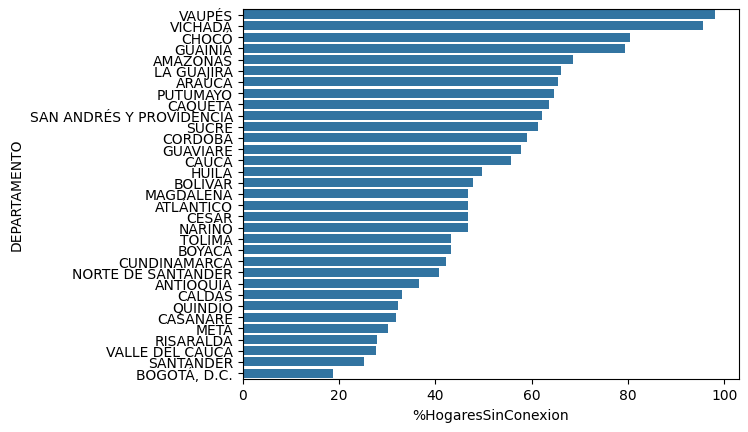

In [ ]:
graficaSinConexion = sns.barplot(data=porcentajesinconexion, y='DEPARTAMENTO', x='%HogaresSinConexion')
plt.show()

In [ ]:
#Ya que analzamos los 5 departamentos con mayor porcentaje de hogares sin conexion, creamos variables para graficar cada departamento
VAUPES = topPorcentajesSinconexion.loc[topPorcentajesSinconexion['DEPARTAMENTO'] == 'VAUPÉS']
VICHADA = topPorcentajesSinconexion.loc[topPorcentajesSinconexion['DEPARTAMENTO'] == 'VICHADA']
CHOCÓ = topPorcentajesSinconexion.loc[topPorcentajesSinconexion['DEPARTAMENTO'] == 'CHOCÓ']
GUAINÍA = topPorcentajesSinconexion.loc[topPorcentajesSinconexion['DEPARTAMENTO'] == 'GUAINÍA']
AMAZONAS = topPorcentajesSinconexion.loc[topPorcentajesSinconexion['DEPARTAMENTO'] == 'AMAZONAS']

In [ ]:
VAUPES

,DEPARTAMENTO,%Costoso,%NoConsiderado,%NoDispositivo,%AccesoSinCosto,%NoSabeUsar,%NoCobertura,%PorSeguridad
31,VAUPÉS,27.946989,23.250407,3.890568,0.736263,7.176626,36.867395,0.116252


In [ ]:
#creamos una variable para organizar mejor y quede mas facil al momento de graficas, transformando las columnas de razones en filas y su contenido en otra columna
vaupes=pd.melt(VAUPES, id_vars=['DEPARTAMENTO'], value_vars=['%Costoso', '%NoConsiderado',	'%NoDispositivo',	'%AccesoSinCosto',	'%NoSabeUsar',	'%NoCobertura',	'%PorSeguridad'])
vichada=pd.melt(VICHADA, id_vars=['DEPARTAMENTO'], value_vars=['%Costoso', '%NoConsiderado',	'%NoDispositivo',	'%AccesoSinCosto',	'%NoSabeUsar',	'%NoCobertura',	'%PorSeguridad'])
choco=pd.melt(CHOCÓ, id_vars=['DEPARTAMENTO'], value_vars=['%Costoso', '%NoConsiderado',	'%NoDispositivo',	'%AccesoSinCosto',	'%NoSabeUsar',	'%NoCobertura',	'%PorSeguridad'])
guainia=pd.melt(GUAINÍA, id_vars=['DEPARTAMENTO'], value_vars=['%Costoso', '%NoConsiderado',	'%NoDispositivo',	'%AccesoSinCosto',	'%NoSabeUsar',	'%NoCobertura',	'%PorSeguridad'])
amazonas=pd.melt(AMAZONAS, id_vars=['DEPARTAMENTO'], value_vars=['%Costoso', '%NoConsiderado',	'%NoDispositivo',	'%AccesoSinCosto',	'%NoSabeUsar',	'%NoCobertura',	'%PorSeguridad'])
vaupes.head()

,DEPARTAMENTO,variable,value
0,VAUPÉS,%Costoso,27.946989
1,VAUPÉS,%NoConsiderado,23.250407
2,VAUPÉS,%NoDispositivo,3.890568
3,VAUPÉS,%AccesoSinCosto,0.736263
4,VAUPÉS,%NoSabeUsar,7.176626


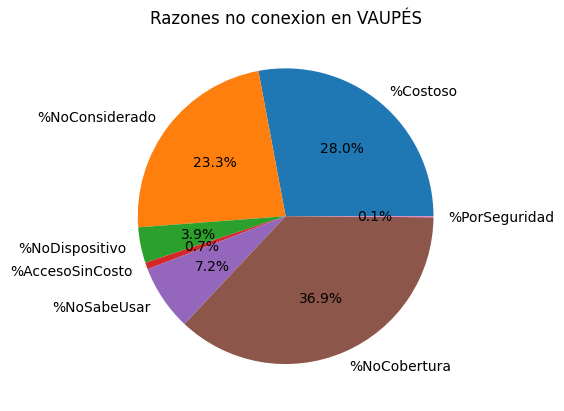

In [ ]:
#realizamos un grafico para cada departamento
plt.pie(vaupes['value'], labels=vaupes['variable'], autopct='%1.1f%%')
plt.title('Razones no conexion en VAUPÉS')
plt.show()

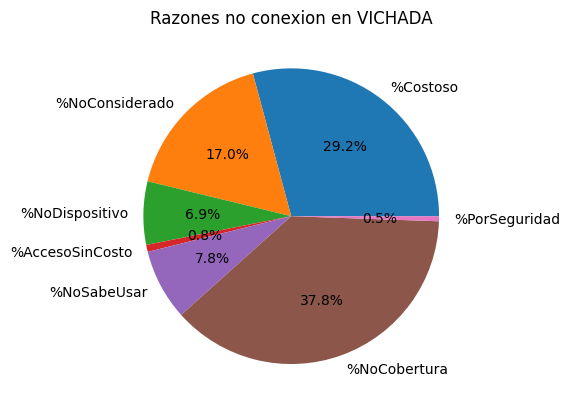

In [ ]:
plt.pie(vichada['value'], labels=vichada['variable'], autopct='%1.1f%%')
plt.title('Razones no conexion en VICHADA')
plt.show()

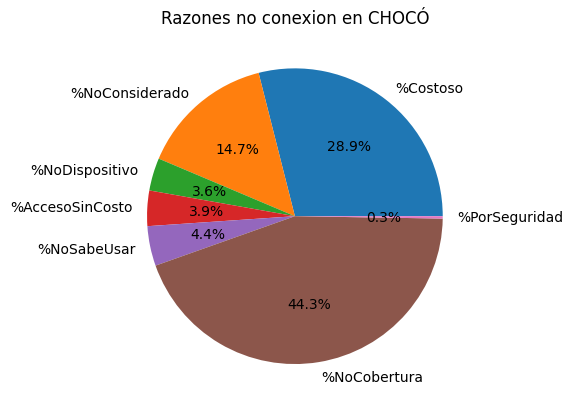

In [ ]:
plt.pie(choco['value'], labels=choco['variable'], autopct='%1.1f%%')
plt.title('Razones no conexion en CHOCÓ')
plt.show()

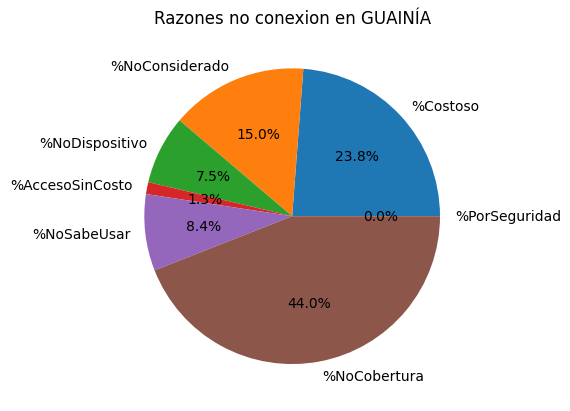

In [ ]:
plt.pie(guainia['value'], labels=guainia['variable'], autopct='%1.1f%%')
plt.title('Razones no conexion en GUAINÍA')
plt.show()

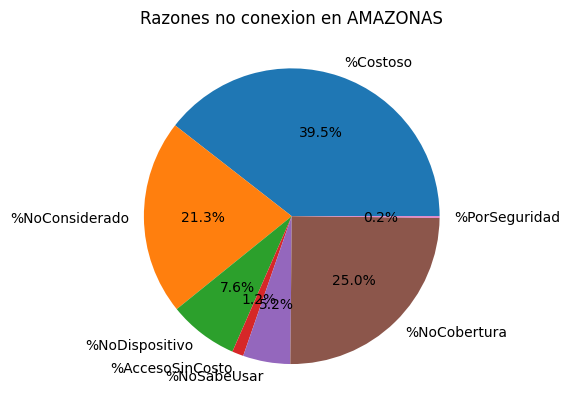

In [ ]:
plt.pie(amazonas['value'], labels=amazonas['variable'], autopct='%1.1f%%')
plt.title('Razones no conexion en AMAZONAS')
plt.show()

In [ ]:
#Aqui buscamos responder si el costo es el mayor inconveniente
costosoEsElMayor = topPorcentajesSinconexion.sort_values(by='%Costoso', ascending=False)
costosoEsElMayor.head(10)

,DEPARTAMENTO,%Costoso,%NoConsiderado,%NoDispositivo,%AccesoSinCosto,%NoSabeUsar,%NoCobertura,%PorSeguridad
28,SUCRE,64.488670,14.355096,5.161929,1.254892,7.916012,6.821644,0.000000
3,ATLÁNTICO,60.371586,15.927394,11.196877,2.934620,4.335929,5.021712,0.211032
13,CUNDINAMARCA,59.837858,24.392716,3.352183,2.312807,4.596481,5.507357,0.000000
22,NORTE DE SANTANDER,59.429385,16.387693,4.807215,2.277598,5.964618,11.132995,0.000000
29,TOLIMA,56.753794,25.312061,1.817072,1.389610,5.935414,8.791087,0.000000
19,MAGDALENA,56.399595,14.128578,6.870669,2.308391,9.350879,10.939812,0.000000
11,CESAR,54.749425,12.935765,13.085522,3.021875,10.601701,5.604642,0.000000
8,CAQUETÁ,53.536789,21.255695,3.447693,1.832679,5.083006,14.791131,0.049623
2,ARAUCA,51.681479,20.222190,4.889622,3.777236,4.288991,15.116112,0.021502
17,HUILA,51.421989,28.746055,2.996294,0.936445,6.685436,9.212682,0.000000


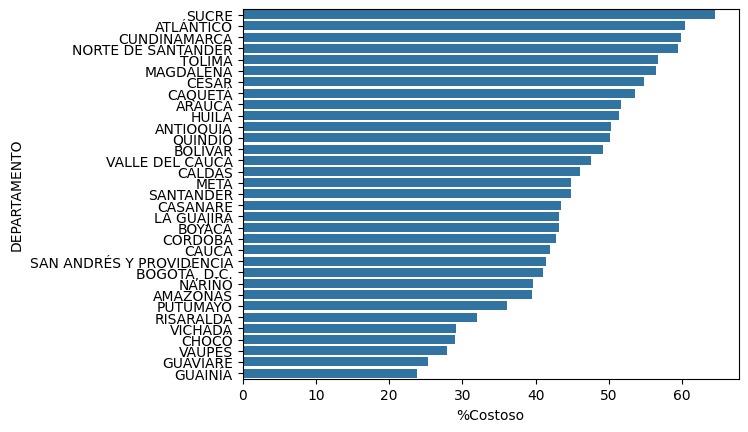

In [ ]:
#aqui hacemos una grafica para ver que departamentos no tienen internet porque es muy costoso
graficaCosto = sns.barplot(data=costosoEsElMayor, y='DEPARTAMENTO', x='%Costoso')
plt.show()


In [ ]:
#aqui queremos ver donde no hay cobertura
nocoberturaEsElMayor = topPorcentajesSinconexion.sort_values(by='%NoCobertura', ascending=False)
nocoberturaEsElMayor.head(10)

,DEPARTAMENTO,%Costoso,%NoConsiderado,%NoDispositivo,%AccesoSinCosto,%NoSabeUsar,%NoCobertura,%PorSeguridad
16,GUAVIARE,25.371459,12.319615,3.041154,1.127739,9.845003,48.278995,0.000000
14,CHOCÓ,28.948186,14.687362,3.574966,3.865590,4.349963,44.315840,0.255923
15,GUAINÍA,23.788703,14.981708,7.522084,1.302757,8.369769,44.017132,0.000000
32,VICHADA,29.176375,17.027906,6.911406,0.764021,7.753996,37.813601,0.547277
31,VAUPÉS,27.946989,23.250407,3.890568,0.736263,7.176626,36.867395,0.116252
9,CASANARE,43.426368,19.084343,3.911127,2.742074,4.135553,26.274126,0.422328
23,PUTUMAYO,36.123901,19.835607,7.849601,3.267654,6.718203,26.057229,0.144615
0,AMAZONAS,39.458590,21.341634,7.610520,1.245104,5.169278,24.972020,0.174874
21,NARIÑO,39.626030,21.712547,4.118869,0.737924,13.865846,19.938043,0.000000
10,CAUCA,41.945275,19.718015,8.051188,1.547860,9.152760,19.584258,0.000000


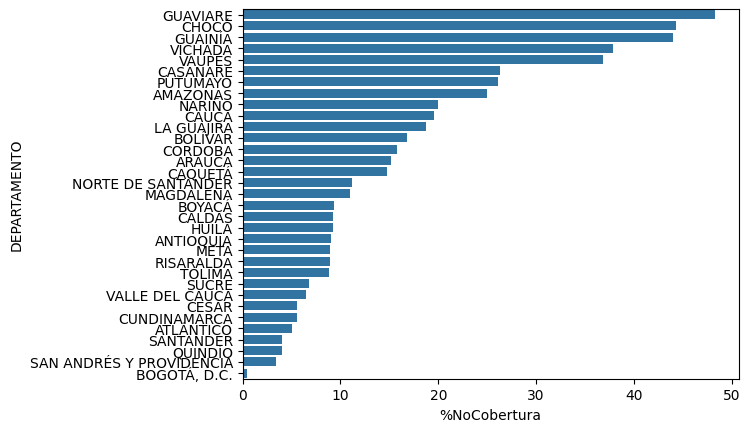

In [ ]:
#como Sabemos que en algunas zonas la cobertura puede ser un problema, entonces buscamos ver los departamentos que tienen como principal problema que no tienen cobertura en la zona
graficaNoCobertura = sns.barplot(data=nocoberturaEsElMayor, y='DEPARTAMENTO', x='%NoCobertura')
plt.show()

In [ ]:
# Aqui ordenamos los datos de los departamentos por seguridad y vemos que no es un dato significativo para la no tenencia de internet
porSeguridad = topPorcentajesSinconexion.sort_values(by='%PorSeguridad', ascending=False)
porSeguridad.head(10)

,DEPARTAMENTO,%Costoso,%NoConsiderado,%NoDispositivo,%AccesoSinCosto,%NoSabeUsar,%NoCobertura,%PorSeguridad
20,META,44.887153,26.098682,5.484226,5.995825,7.758196,8.947147,0.826083
32,VICHADA,29.176375,17.027906,6.911406,0.764021,7.753996,37.813601,0.547277
18,LA GUAJIRA,43.255438,13.744910,14.478504,1.541366,7.741104,18.787473,0.449160
9,CASANARE,43.426368,19.084343,3.911127,2.742074,4.135553,26.274126,0.422328
30,VALLE DEL CAUCA,47.544789,31.483788,6.178246,4.908989,3.082071,6.505719,0.295682
14,CHOCÓ,28.948186,14.687362,3.574966,3.865590,4.349963,44.315840,0.255923
3,ATLÁNTICO,60.371586,15.927394,11.196877,2.934620,4.335929,5.021712,0.211032
0,AMAZONAS,39.458590,21.341634,7.610520,1.245104,5.169278,24.972020,0.174874
5,BOLÍVAR,49.225589,16.419053,8.278884,0.558367,8.596493,16.770145,0.150832
23,PUTUMAYO,36.123901,19.835607,7.849601,3.267654,6.718203,26.057229,0.144615


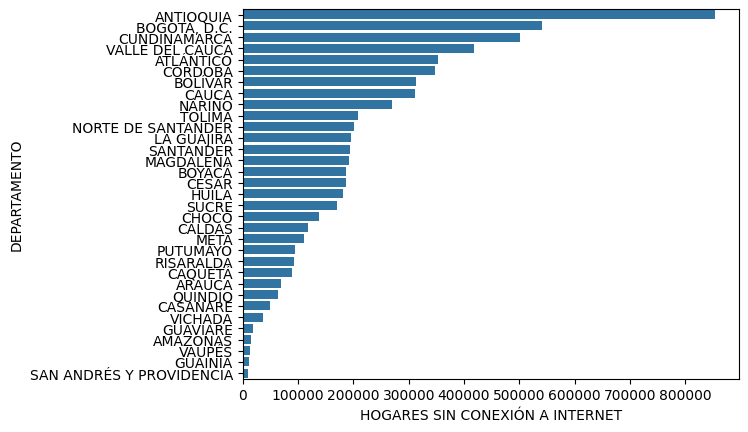

In [ ]:
#aqui graficamos para saber que departamentos tiene mas hogares sin conexion
graficatopHogaresSinConexiona = sns.barplot(data=topHogaresSinConexion, y='DEPARTAMENTO', x='HOGARES SIN CONEXIÓN A INTERNET')
plt.show()

In [ ]:
noConsideraNecesario = topPorcentajesSinconexion.sort_values(by='%NoConsiderado', ascending=False)
noConsideraNecesario.head(10)

,DEPARTAMENTO,%Costoso,%NoConsiderado,%NoDispositivo,%AccesoSinCosto,%NoSabeUsar,%NoCobertura,%PorSeguridad
25,RISARALDA,31.987294,41.991909,6.240141,4.398682,6.432228,8.946527,0.000000
26,SAN ANDRÉS Y PROVIDENCIA,41.399788,41.240721,5.132556,2.290562,6.373277,3.435843,0.095440
24,QUINDÍO,50.166672,36.504252,3.503224,0.942397,4.878657,4.000125,0.000000
7,CALDAS,46.096175,32.090342,3.167753,1.304971,8.054996,9.283204,0.000000
27,SANTANDER,44.795507,32.041410,5.803569,2.026569,11.300490,4.031420,0.000000
30,VALLE DEL CAUCA,47.544789,31.483788,6.178246,4.908989,3.082071,6.505719,0.295682
4,"BOGOTÁ, D.C.",41.059713,29.304598,6.615896,3.851500,18.768172,0.399567,0.000000
17,HUILA,51.421989,28.746055,2.996294,0.936445,6.685436,9.212682,0.000000
20,META,44.887153,26.098682,5.484226,5.995825,7.758196,8.947147,0.826083
1,ANTIOQUIA,50.266920,25.413797,4.942948,2.952528,7.350036,9.073536,0.000000


In [ ]:
noSabeUsar = topPorcentajesSinconexion.sort_values(by='%NoSabeUsar', ascending=False)
noSabeUsar.head(10)


,DEPARTAMENTO,%Costoso,%NoConsiderado,%NoDispositivo,%AccesoSinCosto,%NoSabeUsar,%NoCobertura,%PorSeguridad
4,"BOGOTÁ, D.C.",41.059713,29.304598,6.615896,3.851500,18.768172,0.399567,0.000000
6,BOYACÁ,43.188023,24.864423,3.296592,0.700993,18.603570,9.333041,0.011220
21,NARIÑO,39.626030,21.712547,4.118869,0.737924,13.865846,19.938043,0.000000
27,SANTANDER,44.795507,32.041410,5.803569,2.026569,11.300490,4.031420,0.000000
11,CESAR,54.749425,12.935765,13.085522,3.021875,10.601701,5.604642,0.000000
16,GUAVIARE,25.371459,12.319615,3.041154,1.127739,9.845003,48.278995,0.000000
19,MAGDALENA,56.399595,14.128578,6.870669,2.308391,9.350879,10.939812,0.000000
12,CORDOBA,42.834376,22.219633,7.426969,2.525710,9.204171,15.788278,0.000000
10,CAUCA,41.945275,19.718015,8.051188,1.547860,9.152760,19.584258,0.000000
5,BOLÍVAR,49.225589,16.419053,8.278884,0.558367,8.596493,16.770145,0.150832
